# CNN on the prediction of image — 5 classes

Extended from the original 2-class (Cat / Dog) model to **5 classes**:
**Cat, Dog, Horse, Elephant, Butterfly**.

**Dataset:** [Animals-10 on Kaggle](https://www.kaggle.com/datasets/alessiocorrado99/animals10) — 200 photos per class
(160 for training + 40 for validation) and 10 extra unseen photos per class in `Dataset/test`.
No photo appears in more than one split.

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os

In [26]:
CLASSES = ['Cat', 'Dog', 'Horse', 'Elephant', 'Butterfly']
EMOJI = {'Cat': '🐈', 'Dog': '🐶', 'Horse': '🐎', 'Elephant': '🐘', 'Butterfly': '🦋'}
IMG_SIZE = (224, 224)  # MobileNetV2 input size

# number of photos in each class
pd.DataFrame({split: {c: len(os.listdir(f'Dataset/{split}/{c}')) for c in CLASSES}
              for split in ['train', 'validation']})

,train,validation
Cat,160,40
Dog,160,40
Horse,160,40
Elephant,160,40
Butterfly,160,40


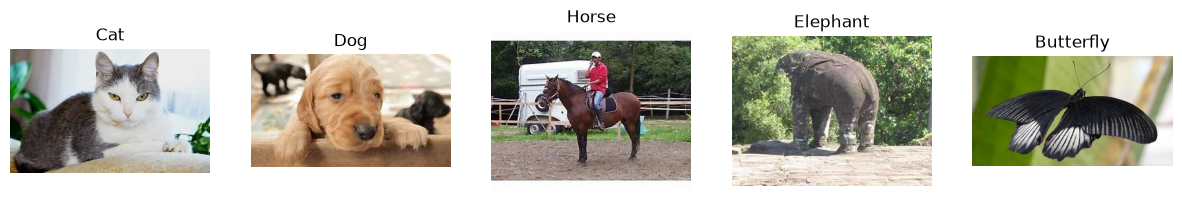

In [27]:
# one sample photo from each class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 3))
for ax, c in zip(axes, CLASSES):
    ax.imshow(image.load_img(f'Dataset/train/{c}/1.jpg'))
    ax.set_title(c)
    ax.axis('off')
plt.show()

In [28]:
cv2.imread('Dataset/train/Cat/1.jpg').shape  #height, width, and channels of image

(186, 300, 3)

Only 160 training photos per class is small, so the training generator uses **data augmentation**
(random rotation, shift, zoom and flip) to create new variations of each photo every epoch.
This reduces overfitting. Validation photos are only rescaled.

In [29]:
train = ImageDataGenerator(rescale=1/255,
                           rotation_range=20,
                           width_shift_range=0.1,
                           height_shift_range=0.1,
                           zoom_range=0.2,
                           horizontal_flip=True)
validation = ImageDataGenerator(rescale=1/255)

In [30]:
train_dataset = train.flow_from_directory('Dataset/train/',
                                           target_size= IMG_SIZE,
                                           classes=CLASSES,
                                           batch_size= 16,
                                           class_mode='categorical')

validation_dataset = validation.flow_from_directory('Dataset/validation/',
                                           target_size= IMG_SIZE,
                                           classes=CLASSES,
                                           batch_size= 16,
                                           class_mode='categorical',
                                           shuffle=False) # use categorical because we have 5 classes (binary only works for 2)

Found 800 images belonging to 5 classes.
Found 200 images belonging to 5 classes.


### Transfer learning with MobileNetV2
Training a CNN from scratch on only 160 photos per class reaches about 60% accuracy.
Instead we use **MobileNetV2**, a CNN already trained on 1.2 million ImageNet photos.
Its convolution layers already know how to detect edges, fur, legs, wings, etc.
We **freeze** those layers and only train a new classification layer for our 5 classes.

In [31]:
base_model = tf.keras.applications.MobileNetV2(input_shape = (224,224,3),
                                               include_top = False,      # remove ImageNet's 1000-class output layer
                                               weights = 'imagenet')
base_model.trainable = False  # freeze the pretrained convolution layers

model = tf.keras.models.Sequential([tf.keras.layers.Input(shape = (224,224,3)),
                                    tf.keras.layers.Rescaling(2, offset=-1),  # [0,1] -> [-1,1], the input range MobileNetV2 expects

                                    base_model,

                                    tf.keras.layers.GlobalAveragePooling2D(),
                                    tf.keras.layers.Dropout(0.3),
                                    tf.keras.layers.Dense(len(CLASSES), activation='softmax') # one output per class

                                   ])

In [32]:
model.compile(loss='categorical_crossentropy',
              optimizer= 'adam',
              metrics=['accuracy'])

In [33]:
# EarlyStopping stops training when validation loss stops improving and keeps the best weights
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_fit = model.fit(train_dataset,
                      validation_data = validation_dataset,
                      epochs = 20,
                      callbacks=[tf.keras.callbacks.CSVLogger('history.csv'), early_stop])
_, accuracy = model.evaluate(validation_dataset, steps=len(validation_dataset))
print(f"Validation accuracy: {round(accuracy * 100, 2)}%")

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - accuracy: 0.6913 - loss: 0.8793 - val_accuracy: 0.9500 - val_loss: 0.2749
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.9375 - loss: 0.2587 - val_accuracy: 0.9600 - val_loss: 0.1595
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.9488 - loss: 0.1806 - val_accuracy: 0.9850 - val_loss: 0.1054
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9712 - loss: 0.1213 - val_accuracy: 0.9800 - val_loss: 0.0914
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.9737 - loss: 0.1045 - val_accuracy: 0.9800 - val_loss: 0.0756
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.9800 - loss: 0.0932 - val_accuracy: 0.9850 - val_loss: 0.0669
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.9800 - loss: 0.0940 - val_accuracy: 0.9800 - val_loss: 0.0748
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.9850 - loss: 0.0680 - val_accuracy

In [34]:
his = pd.read_csv('history.csv')
his.head(10)

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.69125,0.879312,0.950,0.274934
1,1,0.93750,0.258698,0.960,0.159505
2,2,0.94875,0.180618,0.985,0.105419
3,3,0.97125,0.121302,0.980,0.091354
4,4,0.97375,0.104538,0.980,0.075598
5,5,0.98000,0.093163,0.985,0.066927
6,6,0.98000,0.094013,0.980,0.074777
7,7,0.98500,0.067973,0.980,0.058041
8,8,0.97875,0.074278,0.985,0.065337
9,9,0.98125,0.073231,0.980,0.059363


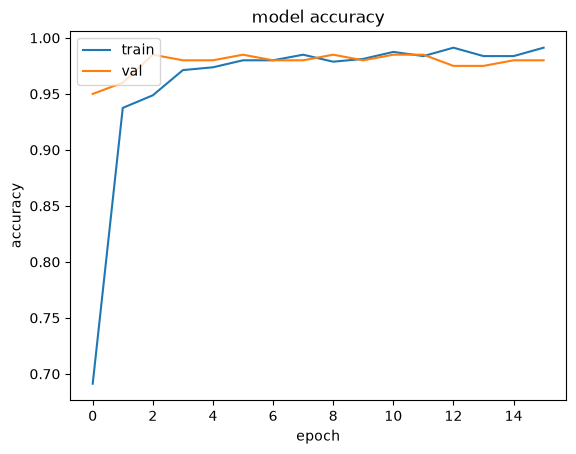

In [35]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

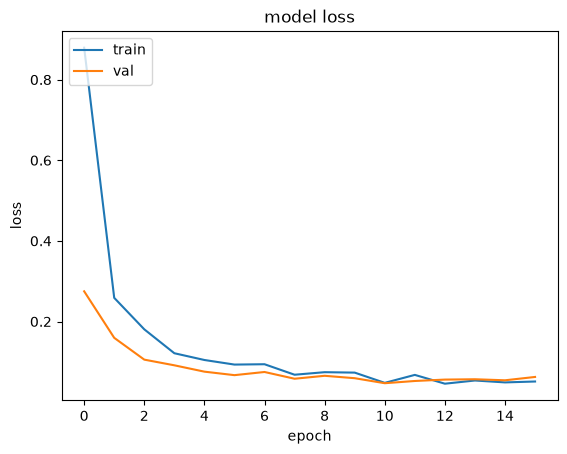

In [36]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [37]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter( y=model_fit.history['val_loss'], name="val_loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['loss'], name="loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['val_accuracy'], name="val_accuracy"),
    secondary_y=True)

fig.add_trace(
    go.Scatter( y=model_fit.history['accuracy'], name="accuracy"),
    secondary_y=True)

# Add figure title
fig.update_layout(
    title_text="Loss/Accuracy of Conv2D Model")

# Set x-axis title
fig.update_xaxes(title_text="Number of Epochs")

# Set y-axes titles
fig.update_yaxes(title_text="<b>primary</b> Loss", secondary_y=False)
fig.update_yaxes(title_text="<b>secondary</b> Accuracy", secondary_y=True)

fig.show()

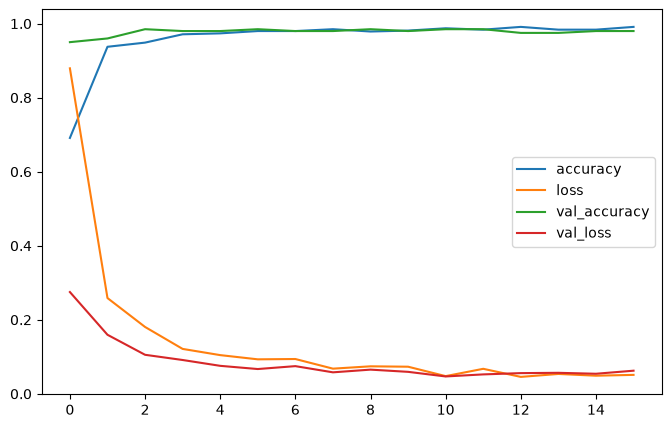

In [38]:
pd.DataFrame(model_fit.history).plot(figsize=(8,5))
plt.show()

### Confusion matrix
Shows which classes the model confuses with each other on the validation set
(rows = true class, columns = predicted class).

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step


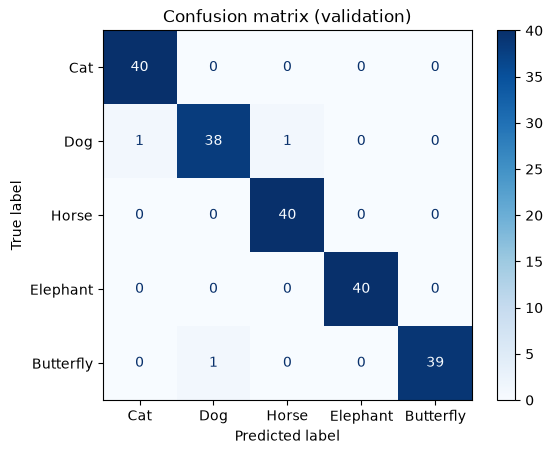

              precision    recall  f1-score   support

         Cat       0.98      1.00      0.99        40
         Dog       0.97      0.95      0.96        40
       Horse       0.98      1.00      0.99        40
    Elephant       1.00      1.00      1.00        40
   Butterfly       1.00      0.97      0.99        40

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [39]:
y_true = validation_dataset.classes
y_pred = np.argmax(model.predict(validation_dataset), axis=1)

ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(cmap='Blues')
plt.title('Confusion matrix (validation)')
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASSES))

In [40]:
model.summary() #Detail of model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,201 (8.69 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 12,812 (50.05 KB)

In [41]:
try:
    plot_model(model, to_file = 'convlstm_model_structure_plot.png', show_shapes = True, show_layer_names = True)
except Exception as e:
    print(e)  # needs pydot + graphviz installed

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [42]:
# Check models first to see if file exists already.
# If not, the model is saved to disk.
os.makedirs('models', exist_ok=True)
if os.path.isfile('models/CNN_predict_model_5class.keras') is False:
    model.save('models/CNN_predict_model_5class.keras')

In [43]:
validation_dataset.class_indices

{'Cat': 0, 'Dog': 1, 'Horse': 2, 'Elephant': 3, 'Butterfly': 4}

In [44]:
def predict_image(path):
    img = image.load_img(path, target_size= IMG_SIZE)
    X = image.img_to_array(img) / 255  # same rescale as training
    X = np.expand_dims(X, axis=0)
    val = model.predict(X, verbose=0)[0]
    return img, CLASSES[np.argmax(val)], np.max(val)

butterfly_00.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_01.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_02.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_03.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_04.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_05.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_06.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_07.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_08.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
butterfly_09.jpg This is  Butterfly 🦋🦋🦋🦋🦋🦋🦋🦋
cat_00.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_01.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_02.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_03.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_04.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_05.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_06.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_07.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_08.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
cat_09.jpg       This is  Cat 🐈🐈🐈🐈🐈🐈🐈🐈
dog_00.jpg       This is  Dog 🐶🐶🐶🐶🐶🐶🐶🐶
dog_01.jpg       This is  Dog 🐶🐶🐶🐶🐶🐶🐶🐶
dog_02.jpg       This is  Dog 🐶🐶🐶🐶🐶🐶🐶🐶
dog_03.jpg       This is  Dog 🐶🐶🐶🐶🐶🐶🐶🐶
dog_

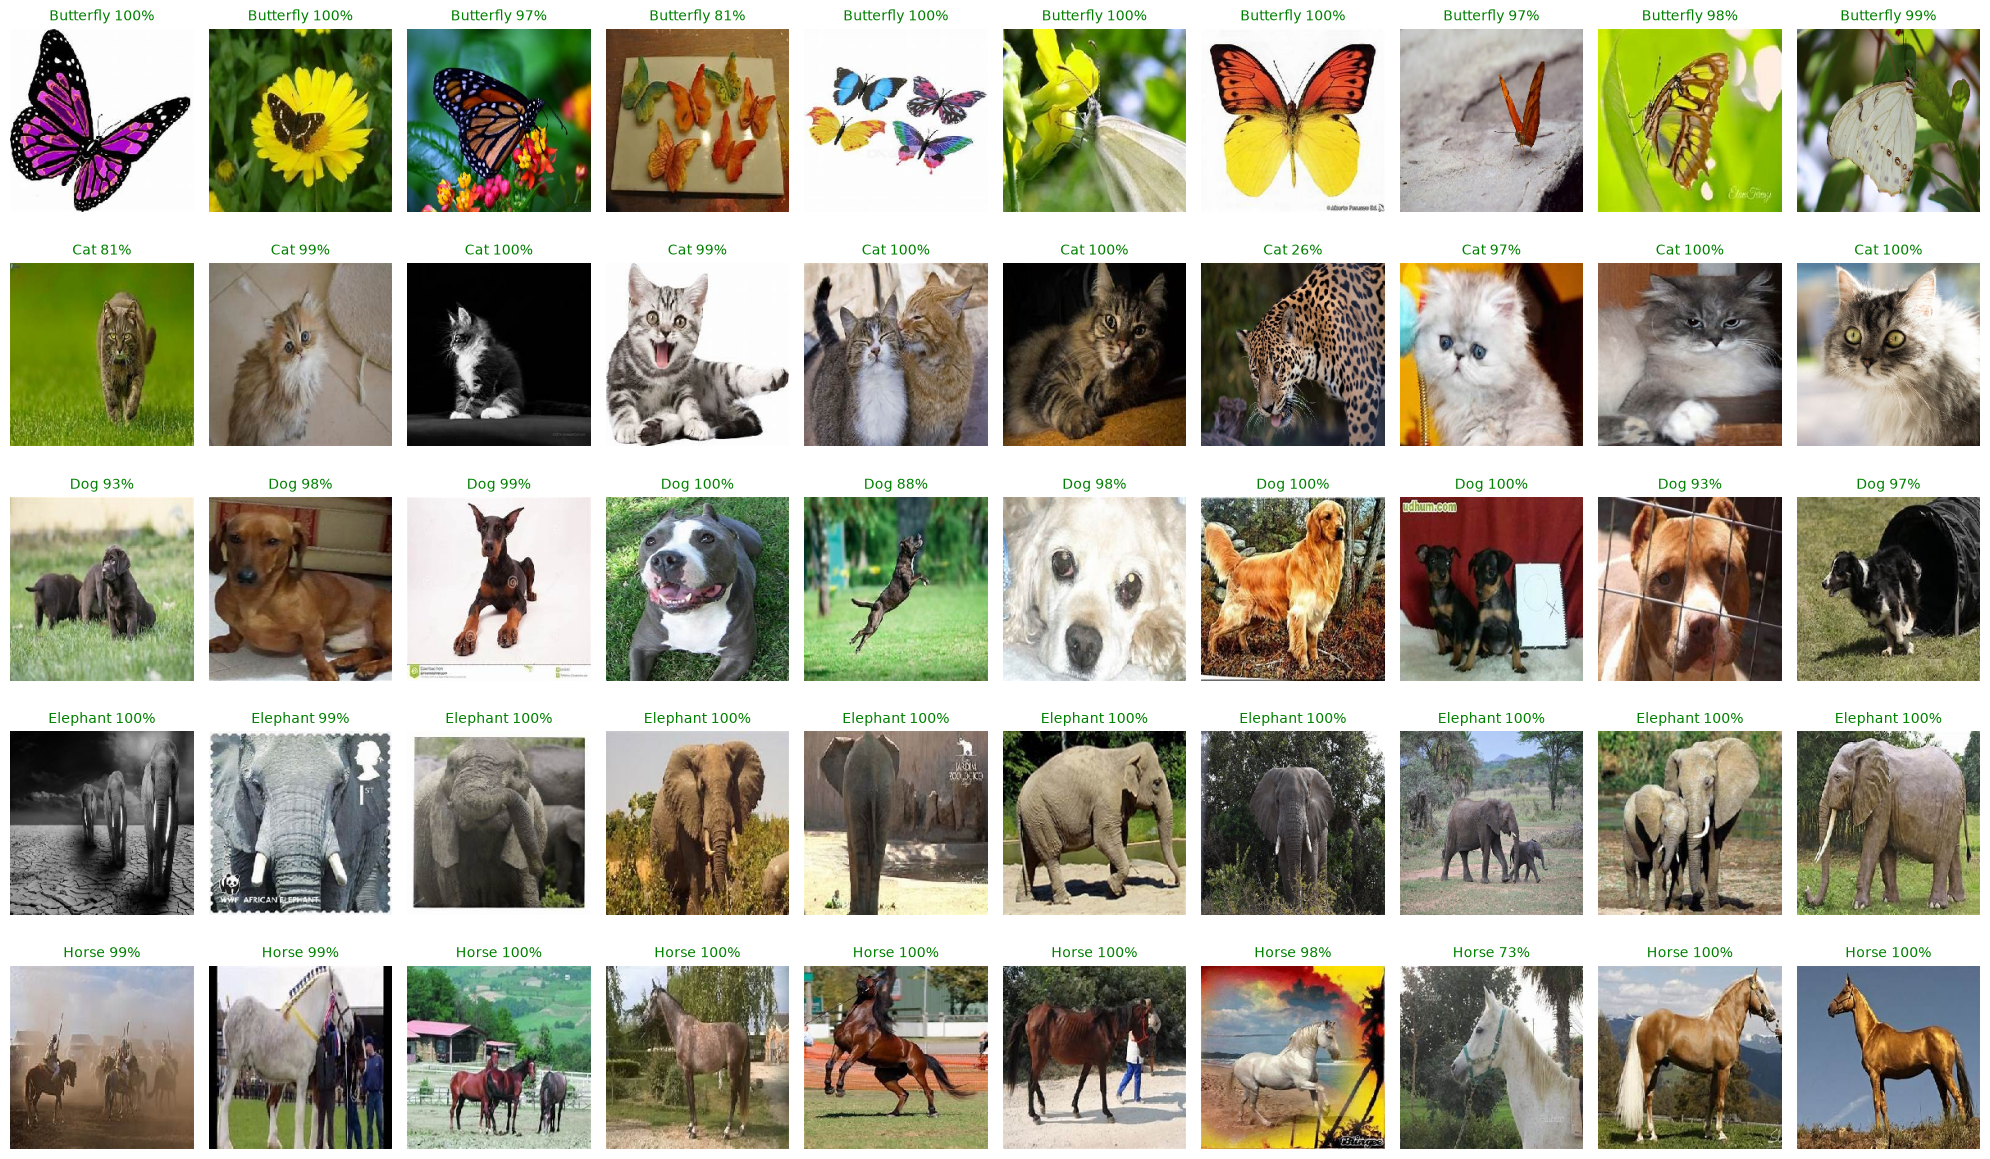

Test accuracy: 50/50 = 100%


In [45]:
dir_path = 'Dataset/test' #path of images that you want to test (file name starts with the true class, e.g. cat_00.jpg)

files = sorted(os.listdir(dir_path))
cols = 10
rows = int(np.ceil(len(files) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 2.4 * rows))
correct = 0

for ax, i in zip(axes.flat, files):
    img, picture, confidence = predict_image(dir_path + '/' + i)
    true_class = i.split('_')[0].capitalize()
    correct += picture == true_class

    ax.imshow(img)
    ax.set_title(f"{picture} {confidence:.0%}", color='green' if picture == true_class else 'red', fontsize=10)
    ax.axis('off')
    print(f"{i:16s} This is  {picture} {EMOJI[picture] * 8}")

for ax in axes.flat[len(files):]:
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Test accuracy: {correct}/{len(files)} = {correct / len(files):.0%}")

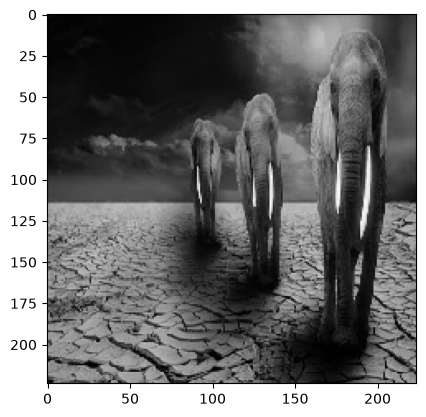

99.9000015258789% is Elephant 🐘


In [46]:
#path of image that you want to predics correct class

path = "Dataset/test/elephant_00.jpg"
img, picture, confidence = predict_image(path)
plt.imshow(img)
plt.show()

print(f"{round(confidence * 100, 2)}%","is" , picture, EMOJI[picture])

In [47]:
from tensorflow.keras.models import load_model
new_model = load_model('models/CNN_predict_model_5class.keras')

In [48]:
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,201 (8.69 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 12,812 (50.05 KB)